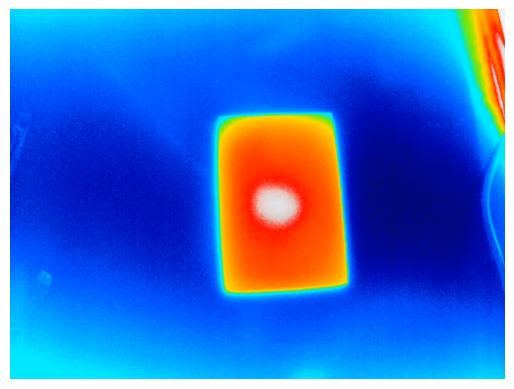

In [38]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# hough lines
# image → grayscale → blur → Canny → HoughLinesP

img_path = "images/plaque.png"
save_path = "outputs/detection/"
img = cv2.imread(img_path)

def _convert_from_bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def _convert_from_bgr_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def _show_bgr_image(img):
    plt.imshow(_convert_from_bgr_to_rgb(img), vmin=0, vmax=255)
    plt.axis("off")
    plt.show()

_show_bgr_image(img)


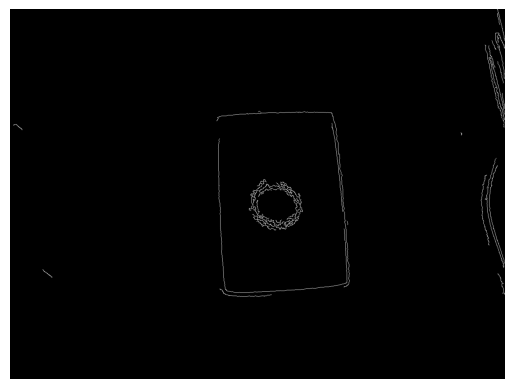

Lines found:  179


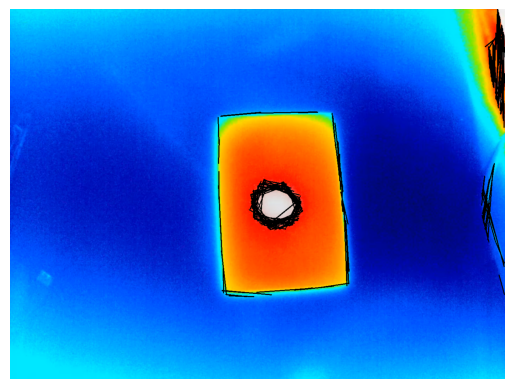

In [29]:
gray = _convert_from_bgr_to_gray(img)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 30, 80)

plt.imshow(edges, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

lines = cv2.HoughLinesP(
    edges,
    rho=10, # distance resolution of the accumulator, in pixels
    theta=np.pi / 180, # angle resolution of the accumulator, in radians
    threshold=60,
    minLineLength=50,
    maxLineGap=60
)

output = img.copy()

if lines is not None:
    print("Lines found: ", len(lines))

    for line in lines:
        x1, y1, x2, y2 = line[0] # each line is shape (1, 4), so [0] unwraps to [x1, y1, x2, y2]
        cv2.line(output, (x1, y1), (x2, y2), (0, 0, 0), 2)
else:
    print("No lines found")

# save image
cv2.imwrite(save_path + "detected_lines.jpg", output)

# show image
plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
plt.axis("off")
plt.show()


Circles found: 64


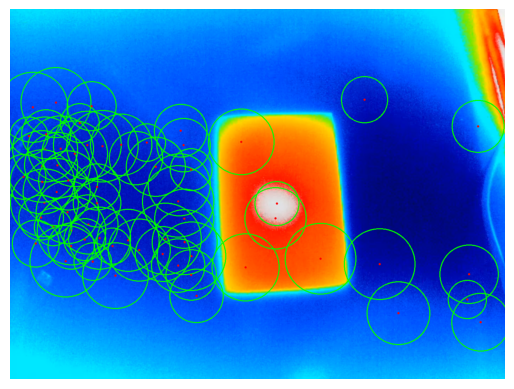

In [35]:
# hogh circles

circles = cv2.HoughCircles(
    blurred,
    cv2.HOUGH_GRADIENT, # detection method (currently the only one available)
    dp=1.2, # inverse ratio of accumulator resolution to image resolution (1 = same size, 2 = half size)
    minDist=40, # minimum distance between the centers of detected circles, in pixels
    param1=30, # higher Canny threshold (used internally for edge detection; lower threshold is half this)
    param2=30, # accumulator threshold for circle centers (lower = more false circles detected)
    minRadius=50, # minimum circle radius to detect, in pixels
    maxRadius=100 # maximum circle radius to detect, in pixels
)

output = img.copy()

if circles is not None:
    circles = np.uint16(np.around(circles))

    print("Circles found:", circles.shape[1])

    for x, y, r in circles[0, :]:
        cv2.circle(output, (x, y), r, (0, 255, 0), 2)
        cv2.circle(output, (x, y), 3, (0, 0, 255), -1)
else:
    print("No circles found")

cv2.imwrite(save_path + "hough_circles.jpg", output)

plt.imshow(_convert_from_bgr_to_rgb(output), vmin=0, vmax=255)
plt.axis("off")
plt.show()

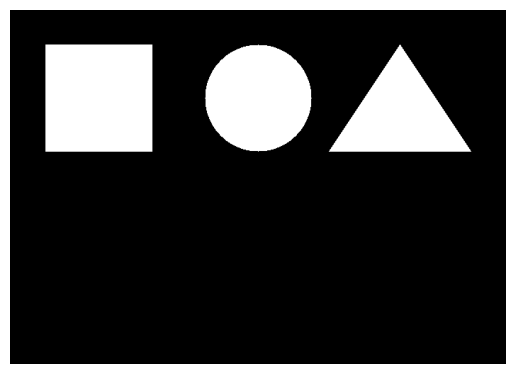

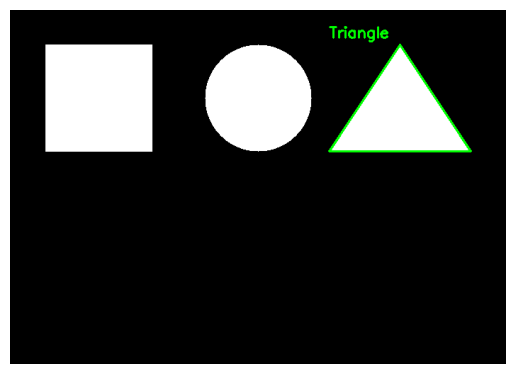

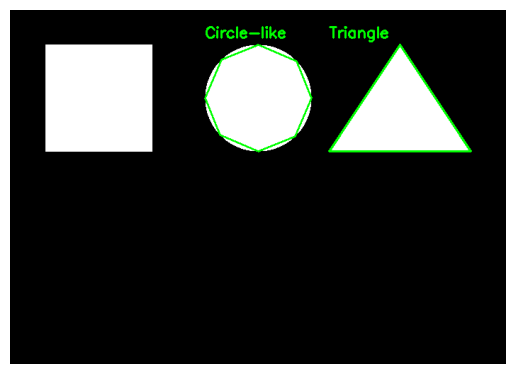

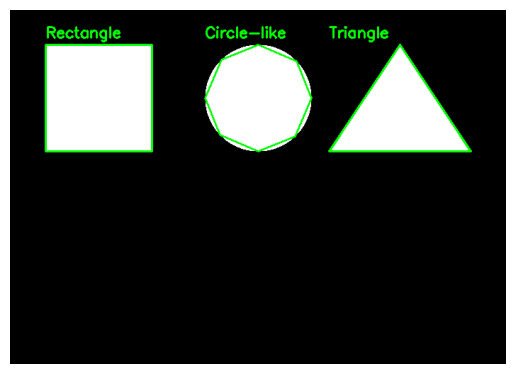

In [ ]:
img = np.zeros((500, 700, 3), dtype=np.uint8)

cv2.rectangle(img, (50, 50), (200, 200), (255, 255, 255), -1)
cv2.circle(img, (350, 125), 75, (255, 255, 255), -1)
pts = np.array([[550, 50], [450, 200], [650, 200]], np.int32)
cv2.fillPoly(img, [pts], (255, 255, 255))

_show_bgr_image(img)

gray = _convert_from_bgr_to_gray(img)
_, mask = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

output = img.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 500:
        continue

    perimeter = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.04 * perimeter, True)

    vertices = len(approx)

    if vertices == 3:
        label = "Triangle"
    elif vertices == 4:
        label = "Rectangle"
    else:
        label = "Circle-like"

    x, y, w, h = cv2.boundingRect(cnt)

    cv2.drawContours(output, [approx], -1, (0, 255, 0), 2)
    cv2.putText(output, label, (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
cv2.imwrite(save_path + "shape_classification.jpg", output)
_show_bgr_image(output)
